<a href="https://colab.research.google.com/github/shanfty/CS_5265_ML_Project/blob/main/CS_5262_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook for ML


Describe my project in a text cell including the following sections:


Background

The Dataset will be looking at a popular online car marketplace known as cars.com. The dataset is from kaggle.com, https://www.kaggle.com/datasets/chancev/carsforsale There is around 9000 data points for different cars including their descriptions and prices for the listings.


Project Description

The project will first be to clean up data, to make sure all the variables can be transformed into the correct class. Looking at the car's features and predicting a price, or vice versa. Taking in some examples of certain features of a car and its price and guessing which other features it has or the ratings it has on the cars.com catelog. Can even look into private vs dealership sales and the different between features & prices of the two. Most likely creating a regression model that predicts a car's price. Future steps could be to look at past years catelogs to see how much the market has been effected from the last couple of years for inflation wise.


Performance Metrix

Looking at the predicted valuation of the car vs the actual price listed. Need to have a range and not be exact because listing price does not neccessarly mean its worth that much or little. Thinking plus or mins $250 to determine if the predicted value is successful. Then look at all the success to find the accuracy of the algorithm. 


## Importing Libraries

In [1]:
# tables and visualizations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

#machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer, StandardScaler
from sklearn import config_context
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

## Loading Data

In [2]:
data_dictionary = pd.read_csv("https://docs.google.com/spreadsheets/d/1A5GPct-AqzSzEFbDWKczS6eKnS3zTV3cLkyWxNBYKrA/export?format=csv&grid=")

display(data_dictionary)

,Feature,Description
0,Year,What year the car model was made in. Stander 4...
1,Make,"The dealer of the car, who created the company..."
2,Model,"The model of the car, Spaces and dashes used n..."
3,Used/New,"String 2 options, 'used' or 'certified'"
4,Price,"Price of the car following this format $xxx,xxx"
5,ConsumerRating,Rating that the consumer of the car has given ...
6,ConsumerReviews,How many reviews consumers have given. Straigh...
7,SellerType,"Sold from a dealer or private individual, 2 st..."
8,SellerName,"The name of the Seller, can be pretty long wit..."
9,SellerRating,The rating the seller gives to the vehicle 0.0...


In [3]:
cars = pd.read_csv("https://docs.google.com/spreadsheets/d/1L-jeVC6ujsiOxCZ578ngfKm1iuimJOyw8HOz765WVOM/export?format=csv&grid=")
cars = cars.drop('StreetName', axis=1)
cars = cars.drop('SellerName', axis=1)
cars = cars.drop('Stock#', axis=1)
cars = cars.drop('VIN', axis=1)              
cars = cars.dropna(subset=['DealType'])

display(cars.tail(5))
cars.info()

,Year,Make,Model,Used/New,Price,ConsumerRating,ConsumerReviews,SellerType,SellerRating,SellerReviews,...,ReliabilityRating,ExteriorColor,InteriorColor,Drivetrain,MinMPG,MaxMPG,FuelType,Transmission,Engine,Mileage
9374,2019,Subaru,Crosstrek 2.0i Premium,Used,"$27,374",4.7,205,Dealer,4.4,443,...,4.8,Quartz Blue Pearl,Gray,All-wheel Drive,27,33,Gasoline,Automatic CVT,2.0L H4 16V GDI DOHC,15606
9375,2019,Audi,Q8 3.0T Premium,Used,"$61,998",4.8,27,Dealer,4.8,1789,...,4.9,Night Black,Black,All-wheel Drive,17,22,Hybrid,8-Speed Automatic,3.0L V6 24V GDI DOHC Turbo Hybrid,46855
9376,2017,Buick,Enclave Leather,Used,"$26,944",4.8,137,Dealer,4.7,831,...,4.8,Ebony Twilight Metallic,Ebony,All-wheel Drive,15,22,Gasoline,6-Speed Automatic,3.6L V6 24V GDI DOHC,62649
9377,2019,Subaru,Forester Premium,Used,"$28,568",4.7,279,Dealer,4.4,680,...,4.8,Crystal Black Silica,Black,All-wheel Drive,26,33,Gasoline,Automatic CVT,2.5L H4 16V GDI DOHC,30760
9378,2019,Hyundai,Santa Fe Ultimate 2.4,Used,"$32,091",4.8,204,Dealer,4.4,1105,...,4.8,Twilight Black,Black,All-wheel Drive,21,27,Gasoline,8-Speed Automatic,2.4L I4 16V GDI DOHC,41645


<class 'pandas.core.frame.DataFrame'>
Int64Index: 9157 entries, 0 to 9378
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   9157 non-null   int64  
 1   Make                   9157 non-null   object 
 2   Model                  9157 non-null   object 
 3   Used/New               9157 non-null   object 
 4   Price                  9157 non-null   object 
 5   ConsumerRating         9157 non-null   float64
 6   ConsumerReviews        9157 non-null   int64  
 7   SellerType             9157 non-null   object 
 8   SellerRating           9157 non-null   float64
 9   SellerReviews          9157 non-null   int64  
 10  State                  9157 non-null   object 
 11  Zipcode                9157 non-null   object 
 12  DealType               9157 non-null   object 
 13  ComfortRating          9157 non-null   float64
 14  InteriorDesignRating   9157 non-null   float64
 15  Perf

## Feature Engineering (Assingment 6)

Changing features to condense data so there is thousands of variants. IE. Tranmissions coloumn changed to either automatic or manual, thats it. Unit testing to see if each feature is transformed correctly. The features made the model perform better and allows for better performance of multiple models.

### Interior Colors
Changing all colors that don't occur at least 25 times & weird string of 'â€“' to other.

In [4]:
Remove = ['–']

value_counts = cars['InteriorColor'].value_counts()
to_remove = value_counts[value_counts <= 24].index

cars['InteriorColor'] = cars['InteriorColor'].apply(lambda x: x if x not in to_remove else 'Other')
cars['InteriorColor'] = cars['InteriorColor'].apply(lambda x: x if x not in Remove else 'Other')

cars['InteriorColor'].value_counts()


Black                   3677
Other                   2424
Jet Black                480
Gray                     410
Ebony                    403
Charcoal                 211
Graphite                 203
Beige                    187
Ivory                    108
Red                      102
Parchment                 98
Charcoal Black            70
Titan Black               67
Ebony / Ebony             62
Brown                     55
Tan                       49
Canberra Beige            49
Ebony Black               44
Ash                       40
Shara Beige               40
Ivory White               39
White                     38
White / Black             36
Cognac                    35
Wheat                     35
Mocha                     34
Cappuccino                31
Okapi Brown               27
Satin Black               27
Macchiato Beige           26
Nougat Brown / Black      25
Almond                    25
Name: InteriorColor, dtype: int64

Black                   3677
Other                   2424
Jet Black                480
Gray                     410
Ebony                    403
Charcoal                 211
Graphite                 203
Beige                    187
Ivory                    108
Red                      102
Parchment                 98
Charcoal Black            70
Titan Black               67
Ebony / Ebony             62
Brown                     55
Tan                       49
Canberra Beige            49
Ebony Black               44
Ash                       40
Shara Beige               40
Ivory White               39
White                     38
White / Black             36
Cognac                    35
Wheat                     35
Mocha                     34
Cappuccino                31
Okapi Brown               27
Satin Black               27
Macchiato Beige           26
Nougat Brown / Black      25
Almond                    25
Name: InteriorColor, dtype: int64

([<matplotlib.patches.Wedge at 0x7f71438d98d0>,
 [Text(0.3348179941552633, 1.0478057600480377, 'Black'),
  Text(-1.0751288302578068, -0.2325897640664355, 'Other'),
  Text(-0.38897930574830697, -1.0289291033397614, 'Jet Black'),
  Text(-0.06167065026445193, -1.0982698807196527, 'Gray'),
  Text(0.24309087832196086, -1.0728032554372016, 'Ebony'),
  Text(0.4620375469691836, -0.9982591372938691, 'Charcoal'),
  Text(0.5986967874775508, -0.9228012552354166, 'Graphite'),
  Text(0.7164497652311965, -0.8346854101397506, 'Beige'),
  Text(0.797116951490991, -0.7580267578692121, 'Ivory'),
  Text(0.8496153458603857, -0.6986800155139242, 'Red'),
  Text(0.8955192142386652, -0.6387842647790909, 'Parchment'),
  Text(0.930829740319397, -0.5861364982125956, 'Charcoal Black'),
  Text(0.9573412379945581, -0.5417543299642811, 'Titan Black'),
  Text(0.980372646341786, -0.49886819331843923, 'Ebony / Ebony'),
  Text(0.9996023658056978, -0.45912428630562774, 'Brown'),
  Text(1.0153444130682332, -0.42317339572700

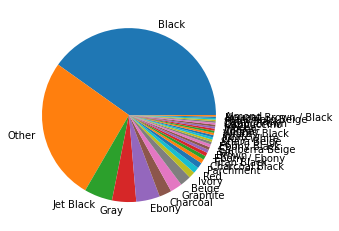

In [5]:
InteriorColor_Count = cars['InteriorColor'].value_counts()
display(InteriorColor_Count)

plt.pie(InteriorColor_Count, labels=InteriorColor_Count.index)

### Exterior Colors

Changing all colors that don't occur at least 25 times & weird string of 'â€“' to other.

In [6]:
value_counts_exterior = cars['ExteriorColor'].value_counts()
to_remove_exterior = value_counts_exterior[value_counts_exterior <= 24].index

cars['ExteriorColor'] = cars['ExteriorColor'].apply(lambda x: x if x not in to_remove_exterior else 'Other')
cars['ExteriorColor'] = cars['ExteriorColor'].apply(lambda x: x if x not in Remove else 'Other')

cars['ExteriorColor'].value_counts()

Other                      3288
Black                       876
White                       327
Gray                        300
Diamond Black               199
                           ... 
Manhattan Gray Metallic      26
Pure White                   26
Galactic Aqua                26
Shadow Metallic              25
Florett Silver Metallic      25
Name: ExteriorColor, Length: 87, dtype: int64

### Drive Train

Changing to FWD, AWD, RWD, 4WD

In [7]:
cars.loc[(cars.Drivetrain == 'Four-wheel Drive'),'Drivetrain']='4WD'
cars.loc[(cars.Drivetrain == 'Front-wheel Drive'),'Drivetrain']='FWD'
cars.loc[(cars.Drivetrain == 'All-wheel Drive'),'Drivetrain']='AWD'
cars.loc[(cars.Drivetrain == 'Rear-wheel Drive'),'Drivetrain']='RWD'

Drivetrain_remove = ['4WD', 'AWD', 'RWD', 'FWD']
cars = cars[cars.Drivetrain.isin(Drivetrain_remove)]
cars['Drivetrain'].value_counts()

AWD    4409
FWD    2326
4WD    1527
RWD     888
Name: Drivetrain, dtype: int64

### Used/New

This is showing used or [make] certified. I.E. 'Dodge Certified' So there is multiple entries for each brand when in reality it should just read new, change all these to new or just certified we already have a make field. 

In [8]:
cars['Used/New'] = cars['Used/New'].apply(lambda x: x if x in 'Used' else 'New')

cars['Used/New'].value_counts()

Used    7684
New     1466
Name: Used/New, dtype: int64

### FuelType

Changing all '–' to 'other'.

In [9]:
cars.loc[(cars.FuelType == '–'),'FuelType']='Other'

cars['FuelType'].value_counts()


Gasoline                         8699
Electric                          159
E85 Flex Fuel                     116
Hybrid                             67
Diesel                             43
Other                              30
Gasoline Fuel                      22
Gasoline/Mild Electric Hybrid       5
Electric Fuel System                4
Flex Fuel Capability                3
Flexible Fuel                       2
Name: FuelType, dtype: int64

### Transmission

Returning Either Automatic or manual

In [10]:
cars.loc[cars['Transmission'].str.contains('Automatic', case=False), 'Transmission'] = 'Automatic'
cars.loc[cars['Transmission'].str.contains('Manual', case=False), 'Transmission'] = 'Manual'
cars_other = ['Automatic', 'Manual']
cars['Transmission'] = cars['Transmission'].apply(lambda x: x if x in cars_other else 'Manual')


cars['Transmission'].value_counts()

Automatic    8959
Manual        191
Name: Transmission, dtype: int64

### Price

Removing the '$' as the start and removing all commas

In [11]:
cars.Price= cars.Price.str.replace(',','.')
cars.Price= cars.Price.str.replace('$','')

notPriced = cars[(cars['Price'] == 'Not Priced')].index
cars.drop(notPriced, inplace=True)

cars["Price"] = cars["Price"].astype(float)
cars['Price'].value_counts()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  


29.995    36
42.998    30
38.998    29
31.998    29
39.998    28
          ..
29.857     1
21.050     1
28.891     1
45.357     1
32.091     1
Name: Price, Length: 4940, dtype: int64

##Visualization

Text(0.5, 1.0, 'Corr')

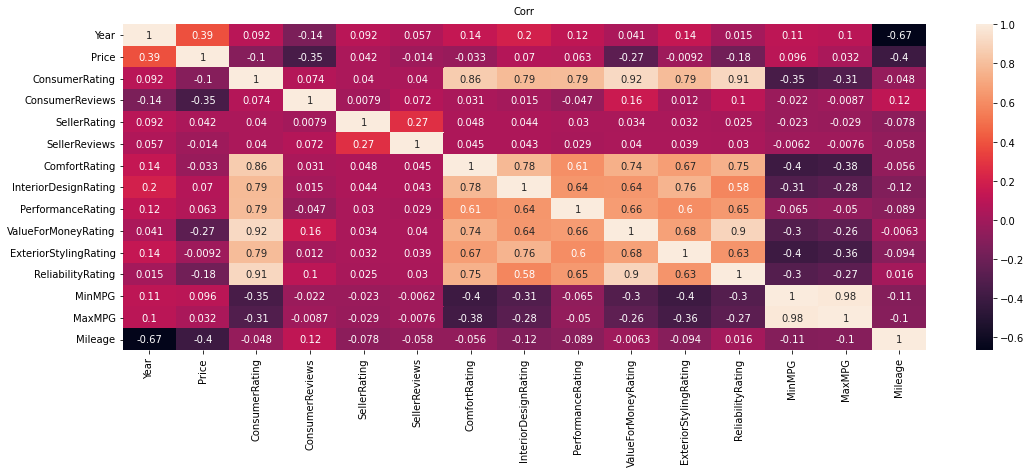

In [12]:
plt.figure(figsize=(18, 6))

# Generating the heatmap
hm = sns.heatmap(cars.corr(),annot=True)

hm.set_title('Corr', fontdict={'fontsize':10}, pad=10)

## ML Pipeline
Standardization for variables, Choosing what models to show the data. Cycling through pipelines add more to transform data based on the models or adding new features.

In [13]:
cars = cars.dropna(subset=['Price'])
y = cars['Price'].values


In [14]:
encoder = OneHotEncoder()
X = encoder.fit_transform(cars.values)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=2345
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8230, 18859)
(915, 18859)
(8230,)
(915,)


# Hyperparameter Tuning

In [16]:
cars.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 9145 entries, 0 to 9378
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   9145 non-null   int64  
 1   Make                   9145 non-null   object 
 2   Model                  9145 non-null   object 
 3   Used/New               9145 non-null   object 
 4   Price                  9145 non-null   float64
 5   ConsumerRating         9145 non-null   float64
 6   ConsumerReviews        9145 non-null   int64  
 7   SellerType             9145 non-null   object 
 8   SellerRating           9145 non-null   float64
 9   SellerReviews          9145 non-null   int64  
 10  State                  9145 non-null   object 
 11  Zipcode                9145 non-null   object 
 12  DealType               9145 non-null   object 
 13  ComfortRating          9145 non-null   float64
 14  InteriorDesignRating   9145 non-null   float64
 15  Perf

In [17]:
linearRegressionModel = LinearRegression()
linearRegressionModel.fit(X_train, y_train)

LinearRegression()

In [18]:
train_score = linearRegressionModel.score(X_train, y_train)
test_score = linearRegressionModel.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9999999999959831
Test Score: 0.863793809743036


In [ ]:
GradientBoostModel = LGBMRegressor(n_estimators=1000)
GradientBoostModel.fit(X_train, y_train)

LGBMRegressor(n_estimators=1000)

In [ ]:
train_score = GradientBoostModel.score(X_train, y_train)
test_score = GradientBoostModel.score(X_test, y_test)
print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9836929521999631
Test Score: 0.8200714281312513


In [ ]:
RandomForestModel = RandomForestRegressor()
RandomForestModel.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
train_score = RandomForestModel.score(X_train, y_train)
test_score = RandomForestModel.score(X_test, y_test)
print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9780748260874663
Test Score: 0.7663627526782473


LinearRegression is performing the best.